# Preprocesado de los datos

In [43]:
import os
import kagglehub
import shutil
import random

## 1. Carga de Datos

In [44]:
# Downloads the latest version of the 'fruits' dataset from Kaggle Hub.
# 'path' will store the local path where the dataset files are saved.
path = kagglehub.dataset_download("aelchimminut/fruits262")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruits262' dataset.
Path to dataset files: /kaggle/input/fruits262


In [45]:
# Define source and destination paths to organize the dataset.
# SOURCE_PATH: Original path of the downloaded dataset from Kaggle.
# DATASET_PATH: Base path where the organized dataset will be created.
# ORIGINAL_DATA_PATH:

SOURCE_PATH = path + "/Fruit-262"
DATASET_PATH = "/content/fruits_dataset"
ORIGINAL_DATA_PATH = "/content/original_data"


In [46]:
# if the original_data_path folder exists, it is deleted
if os.path.exists(ORIGINAL_DATA_PATH):
    shutil.rmtree(ORIGINAL_DATA_PATH)
# copy from source_path to original_data_path
shutil.copytree(SOURCE_PATH, ORIGINAL_DATA_PATH)

'/content/original_data'

## 2. Análisis Volumétrico Inicial

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_class_distribution(dataset_path, threshold):
    """
    Analyzes an image folder classified by categories and generates a bar chart
    showing the class balance, with a critical threshold.

    Args:
        dataset_path (str): Path to the root directory of the dataset.
        threshold (int): Critical threshold value for the number of images per class.
    """
    print(f"Generating plot for: {dataset_path}...")

    # 1. Count images per class.
    class_counts = {}

    if not os.path.exists(dataset_path):
        print(f"Error: Path not found {dataset_path}")
        return

    # Iterate over each category in the dataset.
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            # Count only valid image files.
            num_images = len([f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[category] = num_images

    # Check if the folder is empty or has no images.
    if not class_counts:
        print("No categories or images found in the specified path.")
        return

    # Sort data from highest to lowest image count.
    classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
    categories = [item[0] for item in classes]
    counts = [item[1] for item in classes]

    # Visualization Setup.
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)
    fig, ax = plt.subplots(figsize=(22, 8), dpi=100)

    # Bar colors
    color_excess = '#ff6b6b'
    color_ok = '#4ecdc4'
    bar_colors = [color_excess if count > threshold else color_ok for count in counts]

    # Draw the bar chart.
    bars = ax.bar(range(len(categories)), counts, color=bar_colors,
                  width=0.8, edgecolor='black', linewidth=0.5, alpha=0.9)

    # Draw the threshold.
    ax.axhline(y=threshold, color='#2d3436', linestyle='--', linewidth=2.5,
               label=f'Critical threshold ({threshold})')

    # Upper limit
    max_height = max(counts) if counts else threshold
    ax.set_ylim(0, max_height * 1.35)

    # Place category names at the top of each bar.
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        margin_y = max_height * 0.02
        ax.text(bar.get_x() + bar.get_width() / 2.0, yval + margin_y, categories[i],
                ha='center', va='bottom', rotation=90, fontsize=10,
                fontweight='medium', color='#2d3436')

    # Text and axis formatting.
    ax.set_title("Dataset Distribution", fontsize=20, fontweight='bold', pad=20, color='#2d3436')
    ax.set_xlabel(f'Ordered Categories (Total Classes: {len(categories)})',
                  fontsize=14, labelpad=15, color='#2d3436')
    ax.set_ylabel('Number of Images', fontsize=14, labelpad=15, color='#2d3436')
    ax.set_xticks([])
    sns.despine(left=False, bottom=True, top=True, right=True)
    ax.grid(axis='y', linestyle=':', alpha=0.6, color='gray')
    ax.legend(fontsize=12, loc='upper right', frameon=True, shadow=True, borderpad=1)
    plt.tight_layout()
    plt.show()

In [48]:
def get_class_counts(base_path):
    """
    Counts the number of images per class directly from class folders within the base path.

    Args:
        base_path (str): The root path containing the class folders.

    Returns:
        dict: A dictionary where keys are class names and values are the total
              number of images for that class.
    """
    class_counts = {}
    if not os.path.exists(base_path):
        print(f"Base path not found: {base_path}")
        return class_counts

    # Iterate through each item in the base directory
    for class_name in os.listdir(base_path):
        class_path = os.path.join(base_path, class_name)
        # Check if the item is a directory (representing a class)
        if os.path.isdir(class_path):
            # Filter for common image file extensions and count them
            num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))])
            # Add the class and its image count to the dictionary
            class_counts[class_name] = class_counts.get(class_name, 0) + num_images
    return class_counts

In [49]:
# Get the initial class counts directly from SOURCE_PATH
# SOURCE_PATH is expected to be defined in a previous cell.
initial_class_counts = get_class_counts(SOURCE_PATH)
print(f"Total number of classes in raw dataset: {len(initial_class_counts)}")
print(f"Total number of images in raw dataset: {sum(initial_class_counts.values())}")

Total number of classes in raw dataset: 262
Total number of images in raw dataset: 225639


In [50]:
def print_categories(dataset_path):
    """
    Prints a summary of categories and image distribution within a specific dataset.

    Args:
        dataset_path (str): Path to the root directory of the dataset.
    """
    # Get a sorted list of subfolder names (categories).
    categories = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Dataset Summary")
    print(f"Total categories found: {len(categories)}")
    print(f"Categories: {categories}\n")

    print("Image distribution:")
    # Iterate over each category to count and display the number of images.
    for cat in categories:
        path = os.path.join(dataset_path, cat)
        num_images = len(os.listdir(path))
        print(f"- {cat}: {num_images} images")

In [51]:
print_categories(SOURCE_PATH)

Dataset Summary
Total categories found: 262
Categories: ['abiu', 'acai', 'acerola', 'ackee', 'alligator apple', 'ambarella', 'apple', 'apricot', 'araza', 'avocado', 'bael', 'banana', 'barbadine', 'barberry', 'bayberry', 'beach plum', 'bearberry', 'bell pepper', 'betel nut', 'bignay', 'bilimbi', 'bitter gourd', 'black berry', 'black cherry', 'black currant', 'black mullberry', 'black sapote', 'blueberry', 'bolwarra', 'bottle gourd', 'brazil nut', 'bread fruit', "buddha's hand", 'buffaloberry', 'burdekin plum', 'burmese grape', 'caimito', 'camu camu', 'canistel', 'cantaloupe', 'cape gooseberry', 'carambola', 'cardon', 'cashew', 'cedar bay cherry', 'cempedak', 'ceylon gooseberry', 'che', 'chenet', 'cherimoya', 'cherry', 'chico', 'chokeberry', 'clementine', 'cloudberry', 'cluster fig', 'cocoa bean', 'coconut', 'coffee', 'common buckthorn', 'corn kernel', 'cornelian cherry', 'crab apple', 'cranberry', 'crowberry', 'cupuacu', 'custard apple', 'damson', 'date', 'desert fig', 'desert lime', 'd

Generating plot for: /kaggle/input/fruits262/Fruit-262...


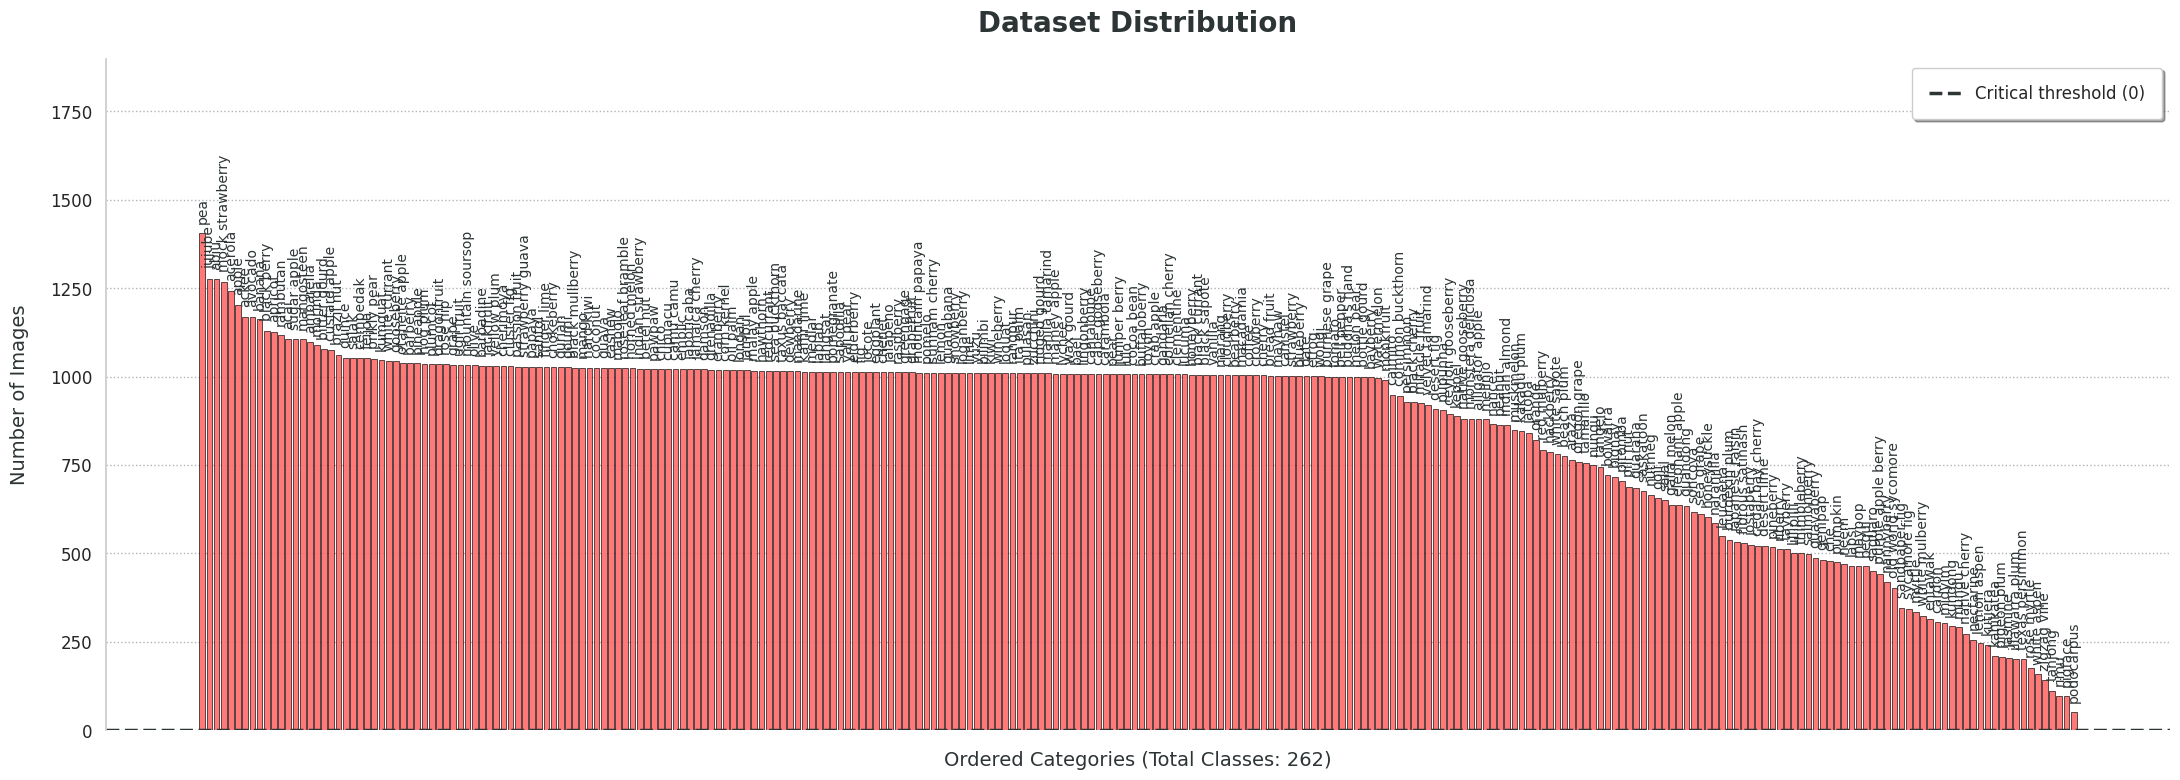

In [52]:
plot_class_distribution(SOURCE_PATH, 0)

## 3. Filtrado de Clases

In [53]:
# 2. Re-definimos la función auxiliar para eliminar clases, ya que el contexto anterior fue rechazado.
def remove_classes_from_path(base_path, classes_list):
    """
    Removes any class folder from a given base directory that is not in the desired list of classes.

    Args:
        base_path (str): Path to the directory containing the classes (e.g., ORIGINAL_DATA_PATH).
        classes_list (list): List of class names that should be kept.

    Returns:
        tuple: (total_images_removed, total_classes_removed)
    """
    # Initialize counters for removed classes and images
    removed_classes_count = 0
    removed_images_count = 0
    if not os.path.exists(base_path):
        print(f"Path not found {base_path}")
        return 0, 0

    # Get a list of current class directories in the base path
    current_classes = [c for c in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, c))]

    # Iterate through each current class to check if it should be removed
    for class_name in current_classes:
        # If the class name is not in the desired list, remove it
        if class_name not in classes_list:
            class_dir = os.path.join(base_path, class_name)
            # Count images before deletion for reporting purposes
            num_images_in_class = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))])
            shutil.rmtree(class_dir) # Delete the entire directory of the unwanted class.
            removed_images_count += num_images_in_class
            removed_classes_count += 1
            print(f"Class removed: '{class_name}' ({num_images_in_class} images)")

    return removed_images_count, removed_classes_count

In [54]:
# 1. We define the 10 fruit classes we want to keep.
# It is crucial that the class names exactly match the folder names in the dataset.
classes = [
    'apple',
    'avocado',
    'mango',
    'banana',
    'cherry',
    'pineapple',
    'strawberry',
    'watermelon',
    'grape',
    'orange'
]

print(f"Desired fruit classes for ORIGINAL_DATA_PATH: {classes}")

# Apply the filtering function to ORIGINAL_DATA_PATH
images_removed_from_original, classes_removed_from_original = remove_classes_from_path(ORIGINAL_DATA_PATH, classes)

print()
print(f"Total number of classes deleted from {ORIGINAL_DATA_PATH}: {classes_removed_from_original}")
print(f"Total number of images deleted from {ORIGINAL_DATA_PATH}: {images_removed_from_original}")

Desired fruit classes for ORIGINAL_DATA_PATH: ['apple', 'avocado', 'mango', 'banana', 'cherry', 'pineapple', 'strawberry', 'watermelon', 'grape', 'orange']
Class removed: 'zigzag vine' (141 images)
Class removed: 'bael' (1008 images)
Class removed: 'coffee' (1003 images)
Class removed: 'miracle fruit' (925 images)
Class removed: 'jujube' (1277 images)
Class removed: 'chenet' (1012 images)
Class removed: 'jasmine' (204 images)
Class removed: 'monstera deliciosa' (881 images)
Class removed: 'velvet tamarind' (920 images)
Class removed: 'tamarillo' (756 images)
Class removed: 'thimbleberry' (500 images)
Class removed: 'cranberry' (1018 images)
Class removed: 'barbadine' (1031 images)
Class removed: 'mayhaw' (1002 images)
Class removed: 'chico' (1021 images)
Class removed: 'lapsi' (465 images)
Class removed: 'cocoa bean' (1007 images)
Class removed: 'rangpur' (1010 images)
Class removed: 'dewberry' (1015 images)
Class removed: 'grapefruit' (1012 images)
Class removed: 'illawarra plum' (201

Generating plot for: /content/original_data...


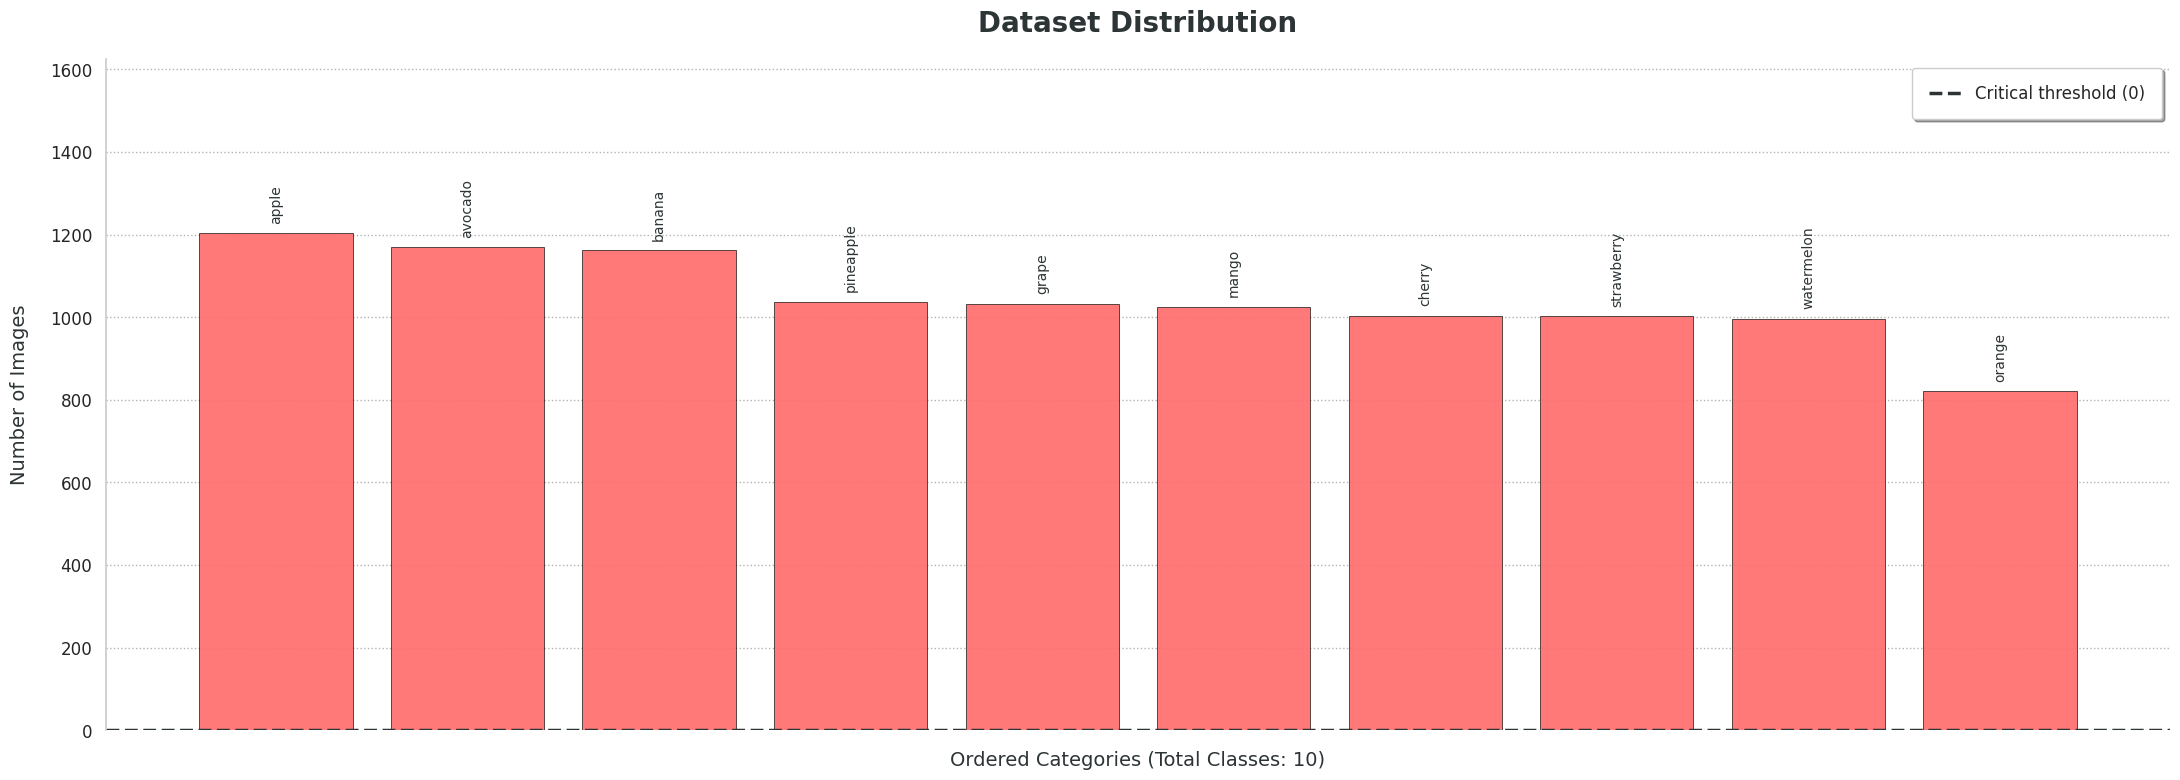

In [55]:
plot_class_distribution(ORIGINAL_DATA_PATH, 0)

## 4. Truncamiento de Clases para Balanceo

In [66]:
def truncate_classes_to_min(data_path):
    """
    Truncates classes in a given directory to match the number of images
    in the smallest class.

    Args:
        data_path (str): Path to the directory containing the classes to truncate.

    Returns:
        int: The total number of images removed during truncation.
    """
    # Dictionary to store current image counts per class
    current_class_counts = {}
    if os.path.exists(data_path):
        # Populate current_class_counts by iterating through class folders
        for class_name in os.listdir(data_path):
            class_path = os.path.join(data_path, class_name)
            if os.path.isdir(class_path):
                num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))])
                current_class_counts[class_name] = num_images

    if not current_class_counts:
        print(f"No images found in {data_path}.")
        return 0

    # Find the minimum number of images among all classes
    min_images_in_class = min(current_class_counts.values())
    print(f"The minimum number of images in a class is: {min_images_in_class}")

    # Initialize counter for images removed during truncation
    images_removed_truncation = 0
    # Iterate through each class to perform truncation if necessary
    for class_name, count in current_class_counts.items():
        # If a class has more images than the minimum, truncate it
        if count > min_images_in_class:
            class_path = os.path.join(data_path, class_name)
            # Get all image files in the class and shuffle them for random selection
            all_images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]
            random.shuffle(all_images)

            # Select images to delete to reach the minimum count
            images_to_delete = all_images[min_images_in_class:]
            for img_name in images_to_delete:
                os.remove(os.path.join(class_path, img_name))
            images_removed_truncation += len(images_to_delete)
            print(f"Class '{class_name}' truncated from {count} to {min_images_in_class} images ({len(images_to_delete)} removed).")

    plot_class_distribution(data_path, min_images_in_class)

    return images_removed_truncation

The minimum number of images in a class is: 821
Generating plot for: /content/original_data...


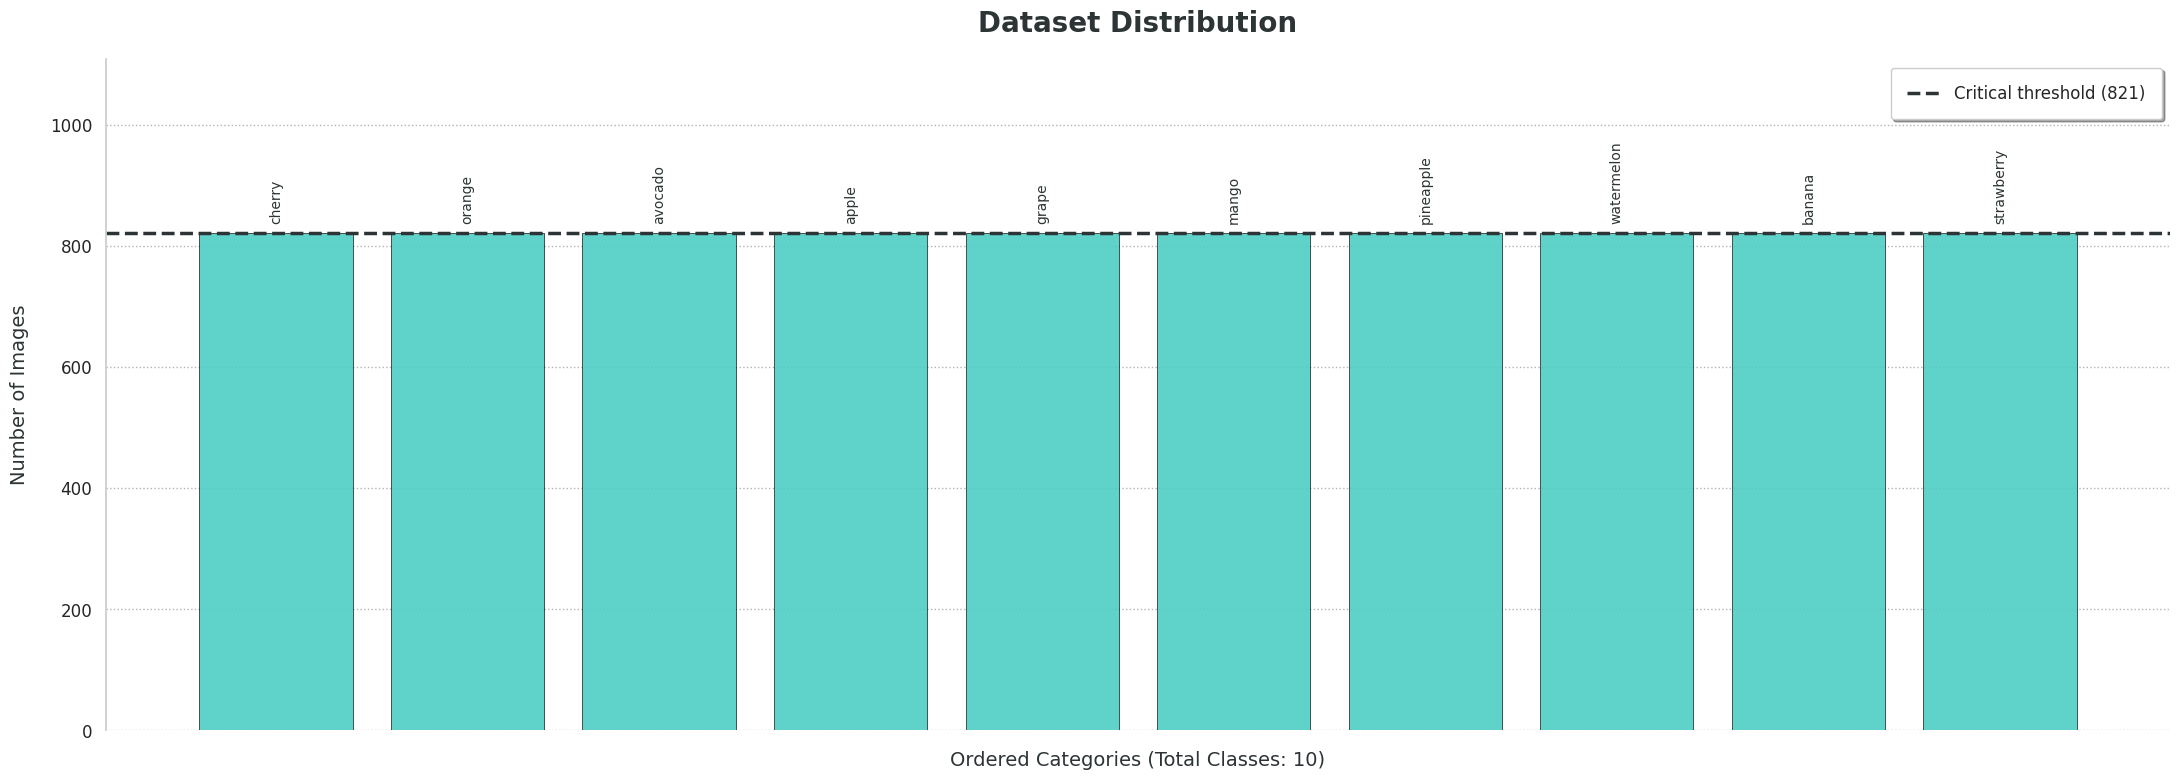

Total images removed in /content/original_data due to truncation: 0.


In [67]:
images_removed = truncate_classes_to_min(ORIGINAL_DATA_PATH)
print(f"Total images removed in {ORIGINAL_DATA_PATH} due to truncation: {images_removed}.")

## 5. Estructura y División de Conjuntos

In [58]:
def split_data(original_data_path, dataset_path, train_ratio, val_ratio, test_ratio):
    """
    Reorganizes and splits the images from the original dataset into Training, Validation, and Test sets
    following the specified proportions.

    Args:
        original_data_path (str): Path to the directory containing the already filtered and truncated classes.
        dataset_path (str): Base path where the new directory structure will be created.
        train_ratio (float): Proportion of images for the Training set.
        val_ratio (float): Proportion of images for the Validation set.
        test_ratio (float): Proportion of images for the Test set.
    """
    # Ensure ratios sum up to 1 (approximately, due to floating point errors)
    if not (0.99 <= (train_ratio + val_ratio + test_ratio) <= 1.01):
        print("Warning: Split ratios do not sum to 1.0.")

    # Clean DATASET_PATH if it already exists
    if os.path.exists(dataset_path):
        print(f"Deleting existing dataset directory: {dataset_path}")
        shutil.rmtree(dataset_path)

    # Create directories for the splits
    TRAIN_PATH = os.path.join(dataset_path, 'Training')
    VAL_PATH = os.path.join(dataset_path, 'Validation')
    TEST_PATH = os.path.join(dataset_path, 'Test')

    os.makedirs(TRAIN_PATH, exist_ok=True)
    os.makedirs(VAL_PATH, exist_ok=True)
    os.makedirs(TEST_PATH, exist_ok=True)

    print(f"Creating split structure in: {dataset_path}")

    # Iterate over each class in original_data_path
    for class_name in os.listdir(original_data_path):
        class_source_path = os.path.join(original_data_path, class_name)

        if os.path.isdir(class_source_path):
            all_images = [f for f in os.listdir(class_source_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]
            random.shuffle(all_images) # Shuffle the images

            num_images = len(all_images)
            num_train = int(num_images * train_ratio)
            num_val = int(num_images * val_ratio)
            # The rest go to test to ensure almost all images are used
            num_test = num_images - num_train - num_val

            train_images = all_images[:num_train]
            val_images = all_images[num_train : num_train + num_val]
            test_images = all_images[num_train + num_val :]

            # Create class subdirectories and copy images
            os.makedirs(os.path.join(TRAIN_PATH, class_name), exist_ok=True)
            os.makedirs(os.path.join(VAL_PATH, class_name), exist_ok=True)
            os.makedirs(os.path.join(TEST_PATH, class_name), exist_ok=True)

            for img in train_images:
                shutil.copy(os.path.join(class_source_path, img), os.path.join(TRAIN_PATH, class_name, img))
            for img in val_images:
                shutil.copy(os.path.join(class_source_path, img), os.path.join(VAL_PATH, class_name, img))
            for img in test_images:
                shutil.copy(os.path.join(class_source_path, img), os.path.join(TEST_PATH, class_name, img))

            print(f"  Class '{class_name}': Training={len(train_images)}, Validation={len(val_images)}, Test={len(test_images)}")

    print("\nDataset distribution completed!")

In [59]:
TRAIN_RATIO = 0.7
VALIDATION_RATIO = 0.1
TEST_RATIO = 0.2
split_data(ORIGINAL_DATA_PATH, DATASET_PATH, TRAIN_RATIO, VALIDATION_RATIO, TEST_RATIO)

Deleting existing dataset directory: /content/fruits_dataset
Creating split structure in: /content/fruits_dataset
  Class 'cherry': Training=574, Validation=82, Test=165
  Class 'orange': Training=574, Validation=82, Test=165
  Class 'avocado': Training=574, Validation=82, Test=165
  Class 'apple': Training=574, Validation=82, Test=165
  Class 'grape': Training=574, Validation=82, Test=165
  Class 'mango': Training=574, Validation=82, Test=165
  Class 'pineapple': Training=574, Validation=82, Test=165
  Class 'watermelon': Training=574, Validation=82, Test=165
  Class 'banana': Training=574, Validation=82, Test=165
  Class 'strawberry': Training=574, Validation=82, Test=165

Dataset distribution completed!


## 6. Verificación de la Distribución Final

### Training

Training set distribution ---
Generating plot for: /content/fruits_dataset/Training...


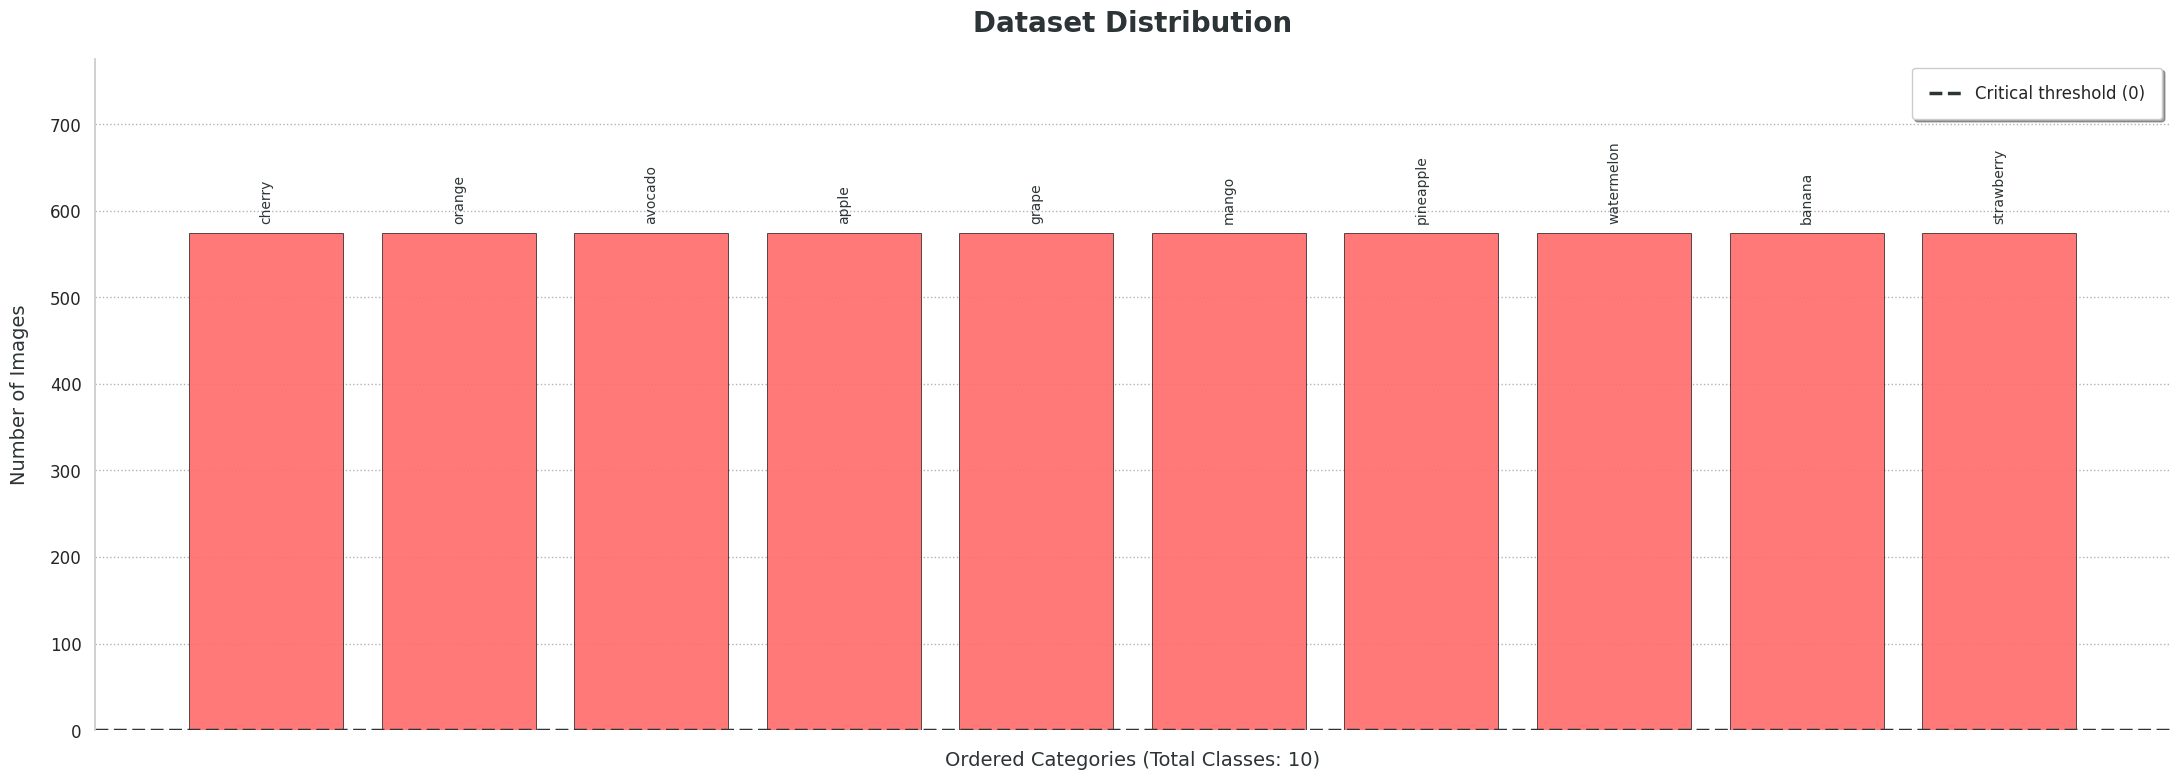

In [60]:
# Verify the distribution in the Training set
print("Training set distribution ---")
TRAINING_PATH = os.path.join(DATASET_PATH, 'Training')
plot_class_distribution(TRAINING_PATH, 0)

### Validation

Validation set distribution ---
Generating plot for: /content/fruits_dataset/Validation...


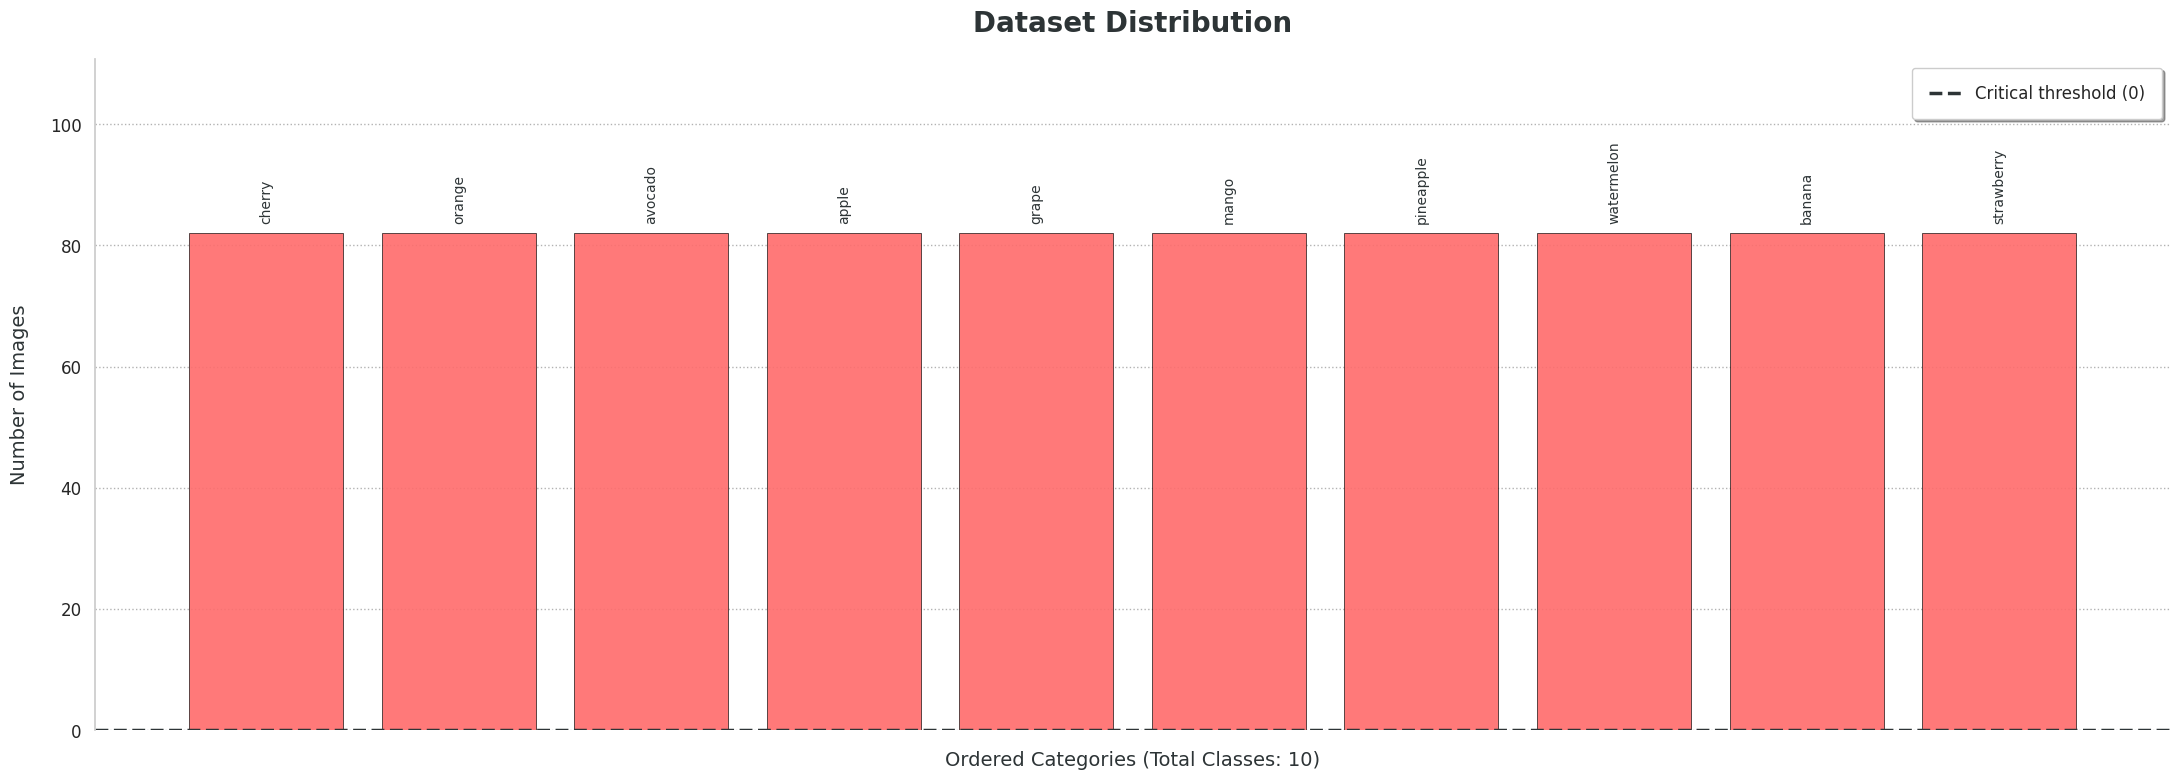

In [61]:
# Verify the distribution in the Validation set
print("Validation set distribution ---")
VALIDATION_PATH = os.path.join(DATASET_PATH, 'Validation')
plot_class_distribution(VALIDATION_PATH, 0)

### Test

Test set distribution ---
Generating plot for: /content/fruits_dataset/Test...


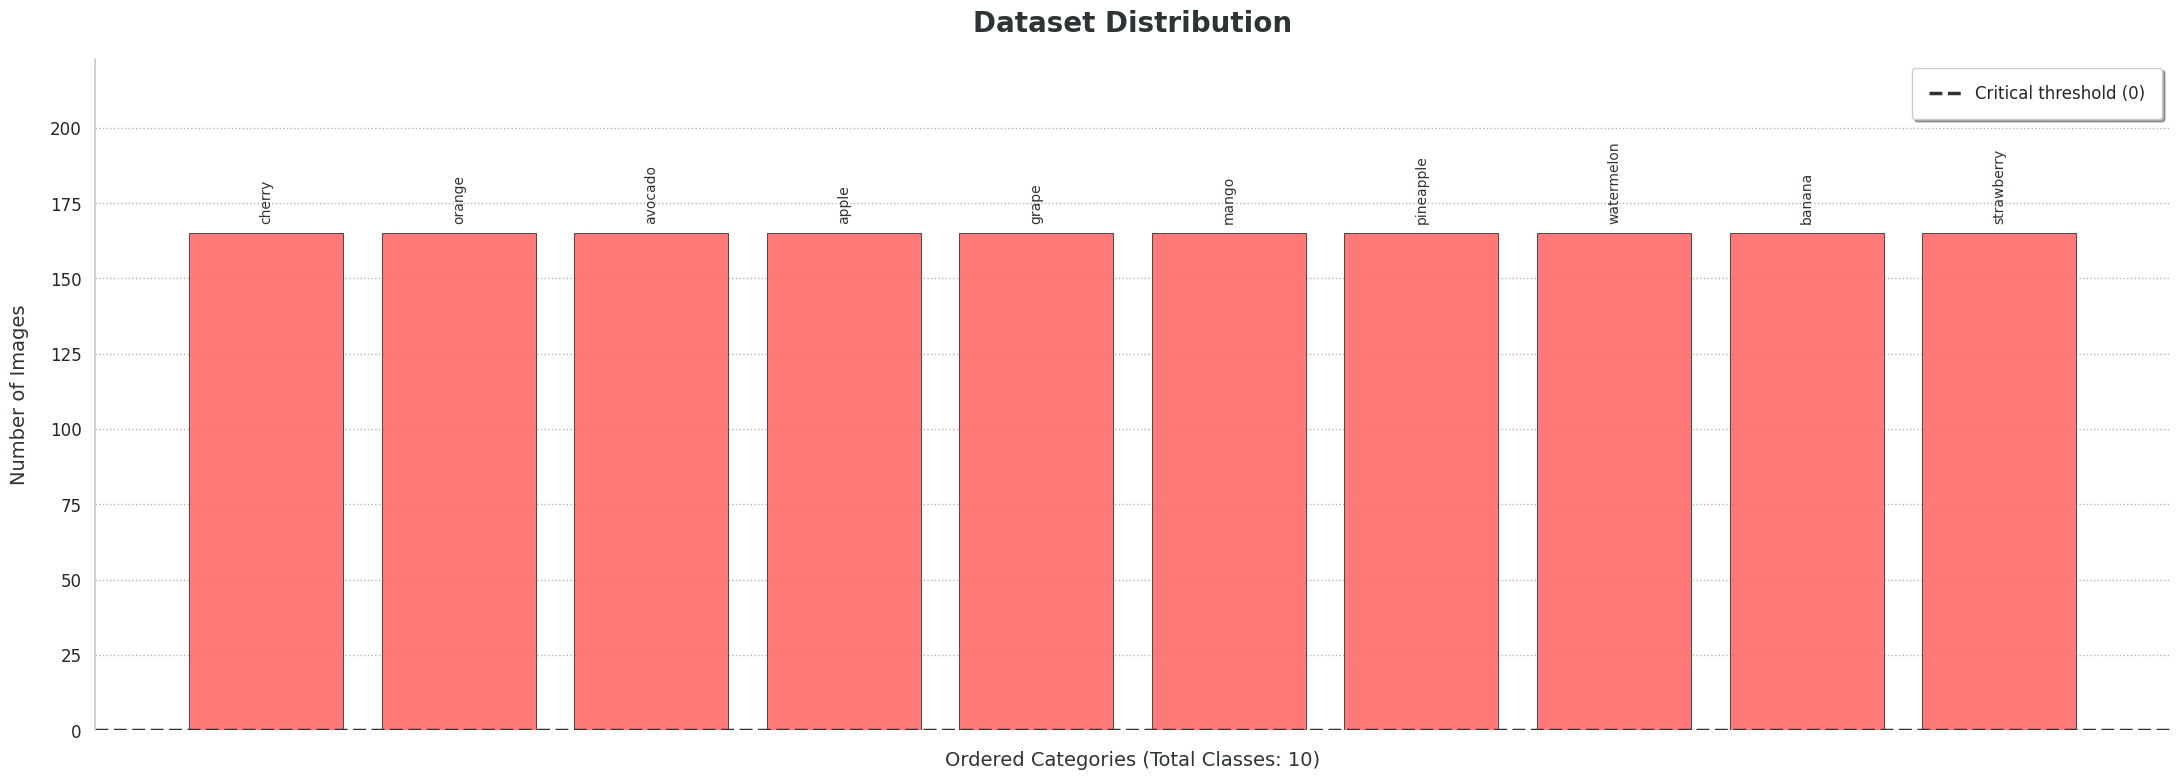

In [62]:
# Verify the distribution in the Test set
print("Test set distribution ---")
TEST_PATH = os.path.join(DATASET_PATH, 'Test')
plot_class_distribution(TEST_PATH, 0)

In [63]:
import shutil
from google.colab import files

# Create a zip archive of the dataset
output_filename = 'fruits_dataset_balanced'
shutil.make_archive(output_filename, 'zip', DATASET_PATH)

# Download the zip file
files.download(f'{output_filename}.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
# Get the list of remaining classes from the Training set
final_classes = sorted([d for d in os.listdir(TRAINING_PATH)])

print(f"Final classes: {len(final_classes)}")
for class_name in final_classes:
    print(f"- {class_name}")

Final classes: 10
- apple
- avocado
- banana
- cherry
- grape
- mango
- orange
- pineapple
- strawberry
- watermelon
